# Tarea 1: EDA dataset de pokémon
>Por: Noam Jansson y Matías Solís

En esta tarea se analizará un dataset de datos sobre los pokémon presentes hasta la $7^{ma}$ generación. Con el objetivo de responde una pregunta de desafío, entender bien los datos y que información podemos obtener. Además de luego de ver los datos también crear una segunda pregunta, una de investigación que se responda a la par que la pregunta desafío que gatilló este EDA.

### Pregunta de desafío

> **¿Dos pokémon con un poder total similar son necesariamente similares?**

## Herramientas a utilizar

Importaremos matplotlib, seaborn y pandas para poder trabajar y visualizar los datos. Los datos son sacados de Kaggle una página con muchos datasets de diversas cosas.

> Link del dataset: https://www.kaggle.com/datasets/rounakbanik/pokemon

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pk = pd.read_csv("/content/drive/MyDrive/pokemon ML/pokemon.csv")
pk.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


## ¿Qué contiene este dataset?

El dataset como digimos antes contiene datos sobre los pokémon de las 7 primeras generaciones (a día de hoy está por salir la décima generación). Las columnas que contiene este set de datos son:
- `name`: El nombre en inglés del pokémon.
- `japanese_name`: El nombre en japones del pokémon.
- `pokedex_number`: El número del pokémon en la Pokedex Nacional (una especie de ID).
- `percentage_male`: El porcentaje de la especie que es macho. Está en blanco si la especie no posee género.
- `type1`: El tipo primario del pokémon.
- `type2`: El tipo secundario del pokémon. En blanco si no posee.
- `classification`: La claseficación del pokémon según la pokedex de Sol y Luna.
- `height_m`: La altura del pokémon en metros.
- `weight_kg`: El peso del pokémon en kilos.
- `capture_rate`: El ratio de captura del pokémon.
- `base_egg_steps`: El número de pasos necesarios para eclosionar al pokémon de un huevo.
- `abilities`: Una lista de las habilidades que puede tener el pokémon.
- `experience_growth`: El crecimiento de experiencia de los pokémon.
- `base_happiness`: La amistad base del pokémon.
- `against_?`: 18 features que indican la magnitud del daño que recibe el pokémon por un ataque recibido de dicho tipo.
- `hp`: El número base de puntos de salud del pokémon.
- `attack`: El ataque base del pokémon.
- `defense`: La defensa base del pokémon.
- `sp_attack`: El ataque especial base del pokémon.
- `sp_defense`: La defensa especial base del pokémon.
- `speed`: La velocidad base del pokémon.
- `base_total`: La suma de todos los stats base del pokémon.
- `generation`: La generación donde fue introducido dicho pokémon.
- `is_legendary`: Indica si el pokémon es legandario o no.

## Primera visualización
Primero hay que revisar los datos con los que estaremos trabajando, algo muy interesante para comparar es el poder base de un pokémon. Para ello vemos su `base_total`, para eso hacemos una distribucion.

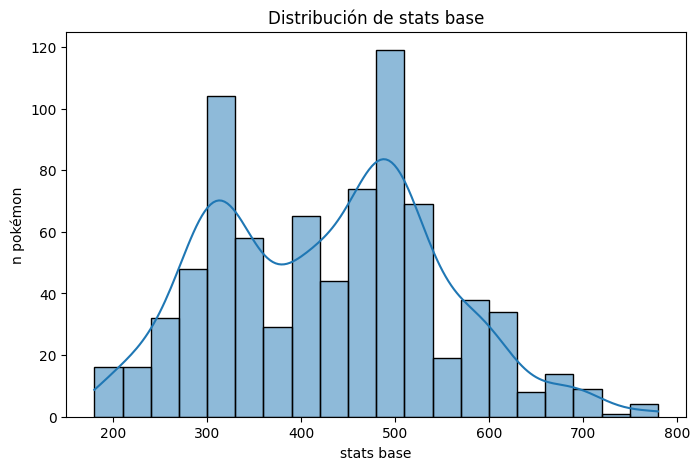

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(pk["base_total"], bins=20, kde=True)
plt.xlabel("stats base")
plt.ylabel("n pokémon")
plt.title("Distribución de stats base")
plt.show()

Aquí vimos que existe un problema en los datos, existen datos que a nuestro conocimiento previo no deberian exitir. Resulta que el creador a la hora de incluir las "Mega-Evoluciones" (formas transitorias que incrementan el poder de un pokémon) reescribió las stats del pokémon con las de su Mega, por lo cual existía una sobreestimacion de stats en algunos pokémon.
También sucedió con pokémon que tienen formas regionales u algun tipo de forma extra, los datos de cada pokémon estarían sobreesquitos con lo de su forma regional o forma alterna.

Para corregir todo esto fuimos valor por valor corrigiendo esto.

In [5]:
pk_bien = pd.read_csv("/content/drive/MyDrive/pokemon ML/pokemon_arreglado.csv")
pk_bien.head()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,3,100,100,80,grass,poison,100.0,1,0
3,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


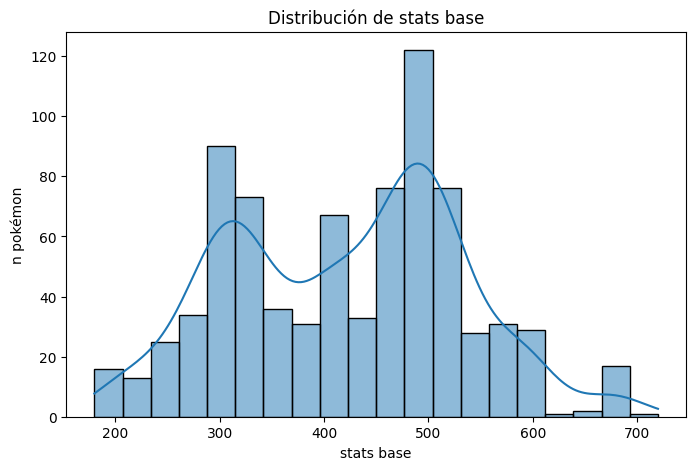

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(pk_bien["base_total"], bins=20, kde=True)
plt.xlabel("stats base")
plt.ylabel("n pokémon")
plt.title("Distribución de stats base")
plt.show()

## Pregunta de Investigación
Ahora podemos ver la distribucion como debía ser desde un inicio. En este punto nos surgió otra pregunta que nos puede guiar en la tarea de explorar este set de datos:
> **¿Qué pokemon es más factible entrenar?**

Al ser tantos pokémon y solo poder llevar 6 hay que discriminar cuales valen la pena entrenar, para poder crear el mejor equipo. Nuestros criterios son las siguientes features:

- Amistad Base
- Stats
- Ratio de captura
- Debilidades totales
- Stats de ataque y defensa

No consideramos la variable `experience_growth` ya que casi todos lo pokémon presentan una similar, y pokémon con mayor stats tienden a tener una mayor `experience_growth`, por lo cual no podemos limitar la selección de un buen pokemon por esta feature. Las demás features no serán consideradas por no ser relaventes en el combate.

## Amistad Base

La amistad base de un pokémon indica que tan afín será a su entrenador. La amistad se puede subir de diversas maneras, pero si el pokémon de por si ya es "buena onda" esta carectarística no se deverá de entrenar tanto, la amistad en combate ayuda, ya que si el pokémon nos quiere podrá aguantar golpes que lo debilitarían, curar problemas de estado por si mismo, dar más golpes críticos y ganar más experiencia (por lo que sube de nivel más rápido).

Así lo primero que hicimos fue comparar la amistad de los pokémon con los stats base de estos para ver si pokémon amistosos suelen ser poderosos o no.

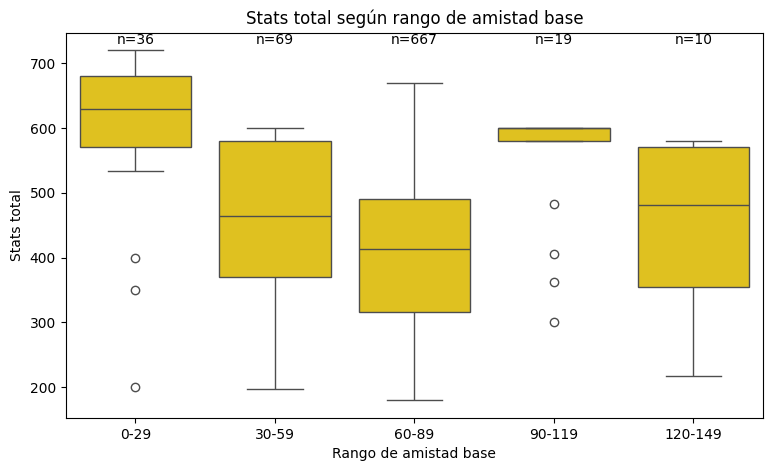

In [7]:
bins = [0, 30, 60, 90, 120, 150]

labels = [
    "0-29",
    "30-59",
    "60-89",
    "90-119",
    "120-149"
]

pk_bien["rango_amistad"] = pd.cut(
    pk_bien["base_happiness"],
    bins=bins,
    labels=labels,
    right=False
)

plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    data=pk_bien,
    x="rango_amistad",
    y="base_total",
    color='gold'
)

plt.xlabel("Rango de amistad base")
plt.ylabel("Stats total")
plt.title("Stats total según rango de amistad base")

# Cantidad de Pokémon por grupo
counts = pk_bien["rango_amistad"].value_counts().sort_index()

for i, count in enumerate(counts):
    plt.text(
        i,
        pk_bien["base_total"].max() + 10,
        f"n={count}",
        ha="center"
    )

plt.show()

Vemos que a medida que subimos las stats los pokemon tienden a tener menos amistad base, aunque existen valores atípicos extremos sobretodo en el rango de 90-119, y que en este mismo rango los stats suelen ser muy altos y concentrados, lo cual es bastante inesperado, pues rompe la tendencia que mostraban los otros datos. Además de esos valores atípicos que llaman la atención en el rango 0-29.

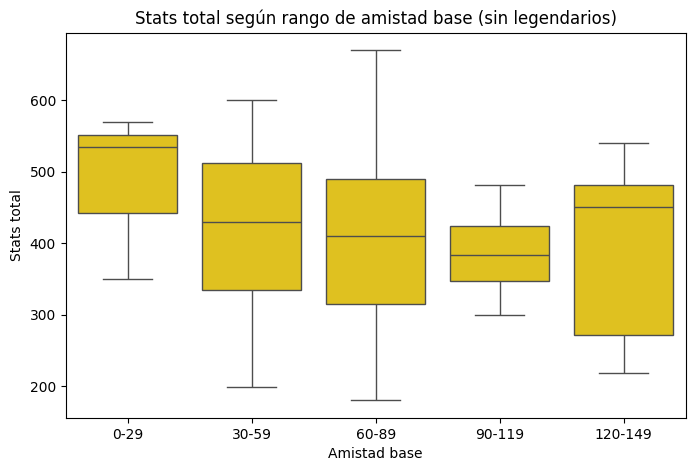

In [8]:
# Excluir Pokémon legendarios
pk_no_legendarios = pk_bien[pk_bien["is_legendary"] == False].copy()

bins = range(0, 151, 30)

labels = [
    "0-29",
    "30-59",
    "60-89",
    "90-119",
    "120-149"
]

pk_no_legendarios["rango_amistad"] = pd.cut(
    pk_no_legendarios["base_happiness"],
    bins=bins,
    labels=labels,
    right=False
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=pk_no_legendarios,
    x="rango_amistad",
    y="base_total",
    color='gold'
)

plt.xlabel("Amistad base")
plt.ylabel("Stats total")
plt.title("Stats total según rango de amistad base (sin legendarios)")

plt.show()

Resulta que muchos pokémon en el rango de 90-119 de amistad, eran legendarios que por Lore eran amigables con humanos, esto siendo porque algunos representan los sueños de los humanos, la voluntad u otras cualidades. Lo mismo sucedió con pokémon con muy baja amistad base con rangos muy bajos de stats, estos siendo pokemon pequeños y poco poderosos que les tienen miedo a los humanos.

## Pokémon Legendarios

Los pokémon legendarios son criaturas raras, que suelen encarnar fuerzas de la naturaleza o criaturas míticas con poderes muy por encima de la media. Es por ello que queríamos ver como se distribuye el poder sin considerar a estas criaturas y si estas eran mucho más fuertes.

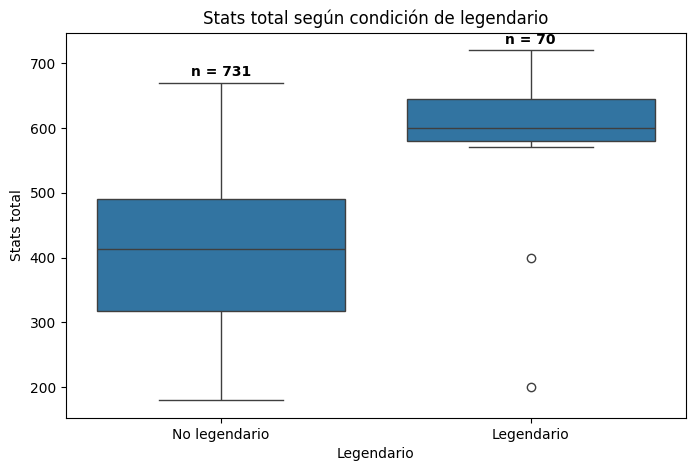

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=pk_bien,
    x="is_legendary",
    y="base_total"
)

conteos = pk_bien["is_legendary"].value_counts()

for i in [0, 1]:
    cantidad = conteos.get(i, 0)

    datos = pk_bien.loc[
        pk_bien["is_legendary"] == i,
        "base_total"
    ]

    if len(datos) > 0:
        ax.text(
            i,
            datos.max() + 10,
            f"n = {cantidad}",
            ha="center",
            fontweight="bold"
        )

plt.xlabel("Legendario")
plt.ylabel("Stats total")
plt.title("Stats total según condición de legendario")

plt.xticks(
    [0, 1],
    ["No legendario", "Legendario"]
)

plt.show()

Vemos que no legendarios abarcan un amplio espectro de stats, los legendarios estan centrados en 600 stats base o superior, los puntos atípicos de legendarios con menor stats también están explicados por Lore. Lo importante a mencionar acá es que un pokémon con poder alto es bastante diferente a si se trata de uno normal o de un legendario, ya que por ejemplo pokémon legendarios pueden ser entregados en eventos especiales o por lo general solo hay 1 de esa especie por juego, a diferencia de los pokémon normales que son más sencillos de conseguir.

## Ratio de Captura

El ratio de captura indíca que tan fácil de atrapar es un pokémon.

Como la tasa de captura generalmente se comparte según la línea evolutiva no nos preocupa mucho perder pokémon muy fuertes que en primera fase eran mas fácil de capturar. Así finalmente podemos considerar pokemon que sean fuertes, pero que al mismo tiempo no sean imposibles de capturar.

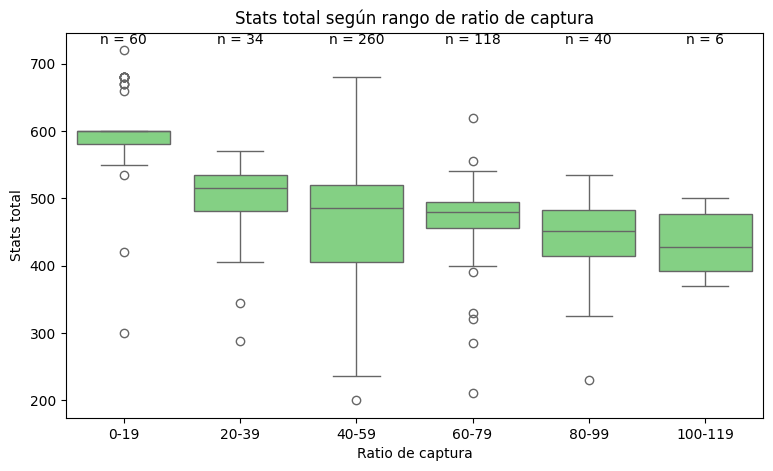

In [10]:
# Convertir ratio de captura a numérico
pk_bien["capture_rate"] = pd.to_numeric(
    pk_bien["capture_rate"],
    errors="coerce"
)

# Rangos de 20 en 20
bins = range(0, 121, 20)

labels = [
    "0-19",
    "20-39",
    "40-59",
    "60-79",
    "80-99",
    "100-119"
]

pk_bien["rango_captura"] = pd.cut(
    pk_bien["capture_rate"],
    bins=bins,
    labels=labels,
    right=False
)

conteos = pk_bien["rango_captura"].value_counts().sort_index()
plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    data=pk_bien,
    x="rango_captura",
    y="base_total",
    color='#77DD77'
)

for i, rango in enumerate(pk_bien["rango_captura"].cat.categories):
    cantidad = conteos.get(rango, 0)

    ax.text(
        i,
        pk_bien["base_total"].max() + 10,
        f"n = {cantidad}",
        ha="center"
    )

plt.xlabel("Ratio de captura")
plt.ylabel("Stats total")
plt.title("Stats total según rango de ratio de captura")

plt.show()

Se ve que los pokémon con ratios de captura más bajos no suelen tener stats tan altos, lo cual es coherente pues se espera que los pokémon fuertes sean difíciles de obtener.

## Debilidad elemental

Para saber como se desempeña en combates cada pokémon definimos una nueva variable `against_total` el cual se compone de las sumas de todas los `against`, esto nos entrega un valor neto de que tan desfavorable es un pokemon respecto al daño que recibe por los demás tipos elementales.
Esto es importante de considerar, ya que si un pokémon es muy fuerte, pero puede ser eliminado muy rápido, quizás no nos interesa entrenarlo.

In [11]:
pk_bien['against_total']=pk_bien['against_bug']+pk_bien['against_dark']+pk_bien['against_dragon']+pk_bien['against_electric']+pk_bien['against_fairy']+pk_bien['against_fight']+pk_bien['against_fire']+pk_bien['against_flying']+pk_bien['against_ghost']+pk_bien['against_grass']+pk_bien['against_ground']+pk_bien['against_ice']+pk_bien['against_normal']+pk_bien['against_poison']+pk_bien['against_psychic']+pk_bien['against_rock']+pk_bien['against_steel']+pk_bien['against_water']

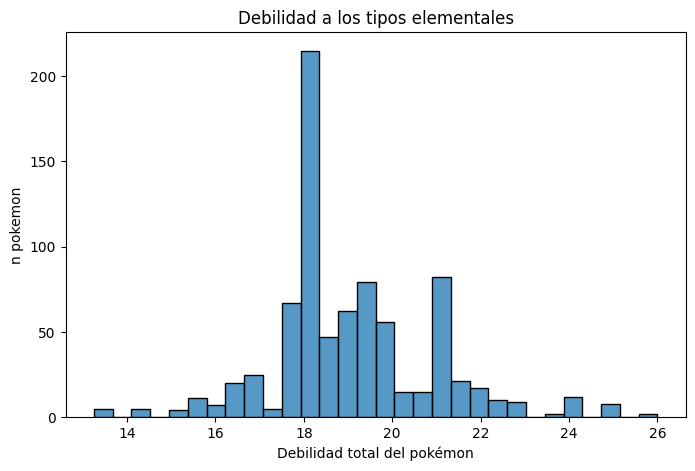

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(pk_bien['against_total'])
plt.xlabel("Debilidad total del pokémon")
plt.ylabel("n pokemon")
plt.title("Debilidad a los tipos elementales")
plt.show()

Luego surge una duda, ¿la cantidad de debildiades de un pokémon estará relacionado directamente con sus stats base?, para eso utilizamos la variable que definimos anteriormente y la comparamos con los stats base.

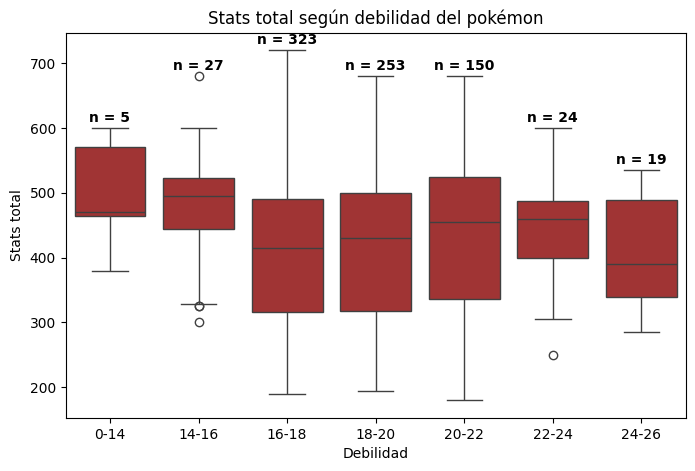

In [13]:
pk_bien["against_total_bin"] = pd.cut(
    pk_bien["against_total"],
    bins=[0, 14, 16, 18, 20, 22, 24, 26],
    labels=["0-14", "14-16", "16-18", "18-20", "20-22", "22-24", "24-26"]
)

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=pk_bien,
    x="against_total_bin",
    y="base_total",
    color="#B22222"
)

conteos = pk_bien["against_total_bin"].value_counts().sort_index()

for i, rango in enumerate(pk_bien["against_total_bin"].cat.categories):

    cantidad = conteos.get(rango, 0)

    datos = pk_bien.loc[
        pk_bien["against_total_bin"] == rango,
        "base_total"
    ]

    if len(datos) > 0:
        ax.text(
            i,
            datos.max() + 10,
            f"n = {cantidad}",
            ha="center",
            fontweight="bold"
        )

plt.xlabel("Debilidad")
plt.ylabel("Stats total")
plt.title("Stats total según debilidad del pokémon")

plt.show()

Vemos que por norma general no existe una tendencia clara, si podemos ver que lo pokémon con mayor stats tienden a tener menos debilidades, pero los demás rangos presentan mucha dispersión o mantienen una mediana casi constante.

## Pokémon atacantes y defensores

Ahora para responder a la pregunta planteada "¿2 pokémon con un poder similar, son iguales?". Para reponder esto de forma tajante decidimos separar pokemon en 2 categorias, estas siendo Atacante y Defensor, estas categorias se eligiron para realizar una comparativa directa, si las stats de ataque (atk + sp.atk) son mayores que las stats de defensas (def + sp.def) se considera un pokemon atacante y visiversa.

Con esto para comparar distintos rangos de Base Stats, ya que si pokemon tienen una stat base igual, pero son de categoria diferente, podemos decir, que aunque tengan un poder similar, son totalmente diferentes.

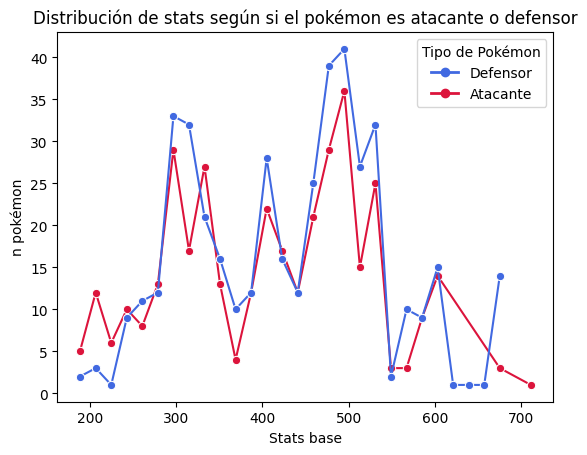

In [14]:
from matplotlib.lines import Line2D
pk_bien["A/D"] = np.where(pk_bien['attack']+pk_bien["sp_attack"] > pk_bien['defense']+pk_bien['sp_defense'], 1, 0)
# Crear rangos
pk_bien["bin"] = pd.cut(pk_bien["base_total"], bins=30)

# Contar datos por rango y por A/D
conteo = pk_bien.groupby(["bin", "A/D"], observed=True).size().reset_index(name="cantidad")

# Obtener el centro de cada rango
conteo["centro"] = conteo["bin"].apply(lambda x: x.mid)

# Graficar
sns.lineplot(
    data=conteo,
    x="centro",
    y="cantidad",
    hue="A/D",
    hue_order=[0, 1],
    palette={0: "crimson", 1: "royalblue"},
    marker="o"
)
# Crear leyenda manualmente
legend_elements = [
    Line2D([0], [0], color="royalblue", marker="o",
           label="Defensor", linewidth=2),
    Line2D([0], [0], color="crimson", marker="o",
           label="Atacante", linewidth=2)
]

plt.legend(
    handles=legend_elements,
    title="Tipo de Pokémon"
)

plt.title('Distribución de stats según si el pokémon es atacante o defensor')
plt.xlabel("Stats base")
plt.ylabel("n pokémon")
plt.show()

Podemos ver que las distribuciones de pokemon atacantes y defensores siguen casi el mismo comportamiento en especial para Stats base intermedios, podemos concluir para la pregunta base, que aunque 2 pokemon presenten Stat base totales iguales no necesariamente se comportan de la misma forma, en este caso, no necesariamente son los 2 atacantes o los 2 defensores.

## Gráfico final

Hasta ahora ya vimos bastantes características que diferencian a los pokémon. Así que falta construir un gráfico que incluya las que consideramos más relevantes, que sería los stats totales, la debilidad, y el tipo de pokémon (atacante/defensor, legendario o no). Este último gráfico será clave pues permite resumir la mayor parte de este análisis y aclarar nuestras 2 preguntas iniciales.

In [15]:
pk_bien["Ata/Def"] = pk_bien["A/D"].map({
    0: "Atacante",
    1: "Defensor"
})

pk_bien["Legendario"] = pk_bien["is_legendary"].map({
    0: "No legendario",
    1: "Legendario"
})

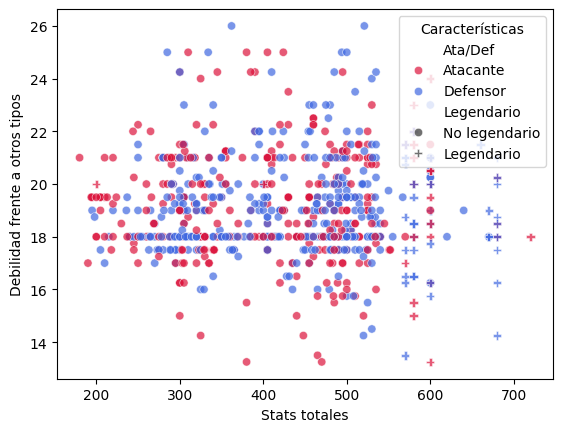

In [16]:
sns.scatterplot(
    data=pk_bien,
    x="base_total",
    y="against_total",
    hue="Ata/Def",
    palette={
        "Atacante": "crimson",
        "Defensor": "royalblue"
    },
    style="Legendario",
    markers={
        "No legendario": "o",
        "Legendario": "P"
    },
    sizes=(30, 300),
    alpha=0.7
)

plt.xlabel("Stats totales")
plt.ylabel("Debilidad frente a otros tipos")
plt.legend(
    title="Características",
    bbox_to_anchor=(1.05, 1)
)
plt.legend(title="Características")
plt.show()

Si lo que queremos es ver a los pokémon más fuertes, hagamos un zoom a los que tengan más de 500 de stats totales. Estos serán los que nos interesan para formar un equipo.

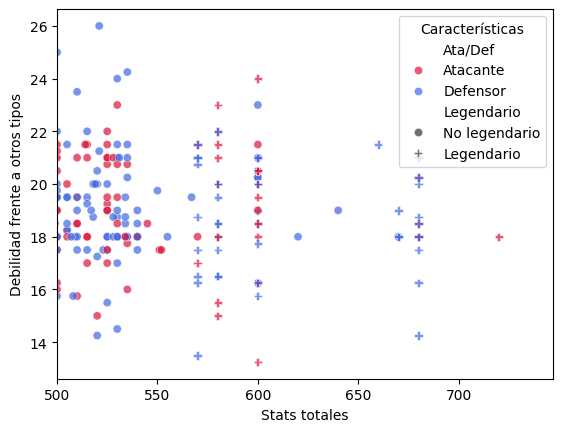

In [17]:
sns.scatterplot(
    data=pk_bien,
    x="base_total",
    y="against_total",
    hue="Ata/Def",
    palette={
        "Atacante": "crimson",
        "Defensor": "royalblue"
    },
    style="Legendario",
    markers={
        "No legendario": "o",
        "Legendario": "P"
    },
    sizes=120,
    alpha=0.7
)

plt.xlabel("Stats totales")
plt.ylabel("Debilidad frente a otros tipos")
plt.legend(
    title="Características",
    bbox_to_anchor=(1.05, 1)
)
plt.xlim(500)
plt.legend(title="Características")
plt.show()

Así notamos que los pokémon más poderosos se caracterizan por ser los legendarios como era de esperarse, pero a demás es destacable notar que la mayoría de ellos son defensores. Por lo que respondiendo a la pregunta de desafío los pokémon con poder similar no son iguales y varian bastante dependiendo de lo que busquemos.

## Conclusión del EDA

Al final hemos encontrado la respuesta a la pregunta desafío, logramos comparar los datos según las features que nosotros consideramos más relevantes. Los pokémon poderosos son diversos y responden también a otras categorías como la especialización de estos en atacantes o defensores, si clasificación como legendario y que además en esta categoría de buscar pokémon fuertes vale mirar otras features como la amistad base o el ratio de captura. Por último para responder nuestra propia pregunta nos gustaría hacer un pequeño desafío más.

## Formacion de Equipo para la Liga

Ahora bien, para responder nuestra pregunta, respecto a "¿qué pokémon vale la pena entrenar?" nos vamos a situar en el contexto que estamos armando un equipo pokémon, el cual se va a enfrentar al desafío mas difícil, ganar la Liga.

 Para eso usaremos una simplificación:

 - el equipo debe tener por lo menos 3 atacantes
 - el equipo debe terner por lo menos 3 defensores

consideraremos todas las features mencionadas anteriormente en el trabajo, y para una mayor comparativa, realziaremos 2 equipos, uno que incluya pokémon legendarios y otro que no.

In [18]:
if "against_total" in pk_bien.columns:
    pk_bien = pk_bien.drop(columns=["against_total"])


cols_against = [
    c
    for c in pk_bien.columns
    if c.startswith("against_") and c != "against_total"
]


for col in cols_against:
    pk_bien[col] = pd.to_numeric(pk_bien[col], errors="coerce")

pk_bien["against_total"] = pk_bien[cols_against].sum(axis=1, numeric_only=True)


pk_bien["capture_rate"] = pd.to_numeric(
    pk_bien["capture_rate"], errors="coerce"
)
pk_bien["base_happiness"] = pd.to_numeric(
    pk_bien["base_happiness"], errors="coerce"
)


pk_bien["rol"] = np.where(
    (pk_bien["attack"] + pk_bien["sp_attack"])
    > (pk_bien["defense"] + pk_bien["sp_defense"]),
    "Atacante",
    "Defensor",
)



def min_max(series):
    s = series.fillna(series.median())
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())



pk_bien["score"] = (
    0.45 * min_max(pk_bien["base_total"])
    - 0.30 * min_max(pk_bien["against_total"])
    + 0.15 * min_max(pk_bien["capture_rate"])
    + 0.10 * min_max(pk_bien["base_happiness"])
)



def seleccionar_equipo(df_input, permitir_legendarios=True):
    df = df_input.copy()
    if not permitir_legendarios:
        df = df[df["is_legendary"] == 0]

    equipo = []
    for rol in ["Atacante", "Defensor"]:
        candidatos = df[df["rol"] == rol].sort_values(
            by="score", ascending=False
        )

        seleccionados = []
        tipos_usados = set()

        for _, pk in candidatos.iterrows():
            tipo_p = pk.get("type1", "")
            if len(seleccionados) < 3:
                if tipo_p not in tipos_usados or len(seleccionados) == 2:
                    seleccionados.append(pk)
                    tipos_usados.add(tipo_p)

        equipo.extend(seleccionados)

    return pd.DataFrame(equipo)


equipo_legendario = seleccionar_equipo(pk_bien, permitir_legendarios=True)
equipo_estandar = seleccionar_equipo(pk_bien, permitir_legendarios=False)

cols_mostrar = [
    "name",
    "rol",
    "type1",
    "base_total",
    "against_total",
    "capture_rate",
    "base_happiness",
    "score",
]

print("=== EQUIPO CON LEGENDARIOS ===")
print(equipo_legendario[cols_mostrar].to_string(index=False))

print("\n=== EQUIPO SIN LEGENDARIOS (ESTÁNDAR) ===")
print(equipo_estandar[cols_mostrar].to_string(index=False))

=== EQUIPO CON LEGENDARIOS ===
   name      rol  type1  base_total  against_total  capture_rate  base_happiness    score
Kartana Atacante  grass         570          16.25         255.0               0 0.404412
 Dialga Atacante  steel         680          14.25           3.0               0 0.393137
Slaking Atacante normal         670          18.00          45.0              70 0.371569
Jirachi Defensor  steel         600          16.25           3.0             100 0.350840
 Arceus Defensor normal         720          18.00           3.0               0 0.338235
 Klefki Defensor  steel         470          13.25          75.0              70 0.334524

=== EQUIPO SIN LEGENDARIOS (ESTÁNDAR) ===
      name      rol  type1  base_total  against_total  capture_rate  base_happiness    score
   Slaking Atacante normal         670          18.00          45.0              70 0.371569
Wishiwashi Atacante  water         620          18.00          60.0              70 0.338831
  Empoleon Atacan

### **Conclusión: Selección del Equipo para la Liga**

El modelo ofrece un buen filtro inicial al evaluar poder (`base_total`), perfil defensivo (`against_total`), captura (`capture_rate`) y amistad (`base_happiness`).

#### **Equipos Seleccionados (3 Atacantes / 3 Defensores)**
* **Con Legendarios**: Kartana, Dialga, Slaking (Atk) | Jirachi, Arceus, Klefki (Def)
* **Sin Legendarios**: Slaking, Wishiwashi, Empoleon (Atk) | Klefki, Floette, Audino (Def)



#### **Limitaciones del Modelo (Simplificación)**
Este análisis es **teórico** y omite mecánicas críticas del combate real:

* **Habilidades**: *Slaking* lidera por sus stats, pero su habilidad *Ausente* lo inutiliza turnos por medio. Tampoco se consideran inmunidades clave como *Levitación*.
* **Naturalezas**: Alteran las stats un $\pm 10\%$, lo que puede arruinar un atacante o cambiar su rol defensivo.
* **Movimientos y EVs**: Un Pokémon defensivo pierde valor si no aprende ataques de soporte/curación o si no tiene buen entrenamiento de EVs.

#### **Veredicto Final**
El modelo da una estructura sólida y balanceada en tipos, pero el *gameplay* (habilidades, naturalezas y *movesets*) determina la victoria real en la Liga.

## Problema de Machine Lerning

Un modelo de machine learning que nos gustaría implementar sería el poder crear un modelo capaz de predecir el desempeño que tendría cierto pokémon en un ambiente competitivo. El competitivo de pokémon va cambiando a cada rato, se añanden nuevos pokémon, se hacen balances de stats o se añaden mecánicas de juego nuevas.

Así el modelo podría evaluar las features que vimos en este EDA, como los stats y la debilidad elemental. Luego el modelo resolvería un problema de clasificación, asignando a los pokémon etiquetas de desempeño, como "Muy recomendable", "No recomendable" o "Medianamente recomendable", que permitan ayudar a decidir si ese pokémon vale la pena usarlo o no.

Los datos que se le podrían dar al modelo para entrenarlo son los pokémon más utilizados del formato del momento y las reglas que cambiarán para el próximo formato. Aunque aquí podrían haber dificultades como las que tuvimos en el EDA de que existan datos inflados por mecánicas de juego como la Mega-evolución que conllevarían un sesgo.





## Uso de IA

Se utilizaron herramientas como ChatGPT únicamente como apoyo para programar los gráficos y que quedaran como nosotros queríamos. No se utilizó en lo que es redacción ni en el análisis de los gráficos que obtuvimos.